Lab 6 - R Programming

KHUSHBOO YADAV

23102A0062

CMPN A

Install Packages

In [5]:
install.packages(c(
  "tidyverse",
  "palmerpenguins",
  "moments",
  "car",
  "effsize"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘pbkrtest’




Load Libraries

In [6]:
library(tidyverse)
library(palmerpenguins)
library(moments)
library(car)
library(effsize)

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




Load Dataset

In [7]:
data("penguins")

head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


In [8]:
str(penguins)

tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


In [9]:
summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

Data Cleaning

In [10]:
colSums(is.na(penguins))

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

In [11]:
penguins_clean <- penguins %>%
  drop_na()

dim(penguins_clean)

[1] 333   8

In [12]:
head(penguins_clean)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007


Basic Dataset Information

In [13]:
cat("Number of observations:", nrow(penguins_clean), "\n")
cat("Number of variables:", ncol(penguins_clean), "\n")

cat("\nSpecies:\n")
print(unique(penguins_clean$species))

cat("\nSex:\n")
print(unique(penguins_clean$sex))

Number of observations: 333 
Number of variables: 8 

Species:
[1] Adelie    Gentoo    Chinstrap
Levels: Adelie Chinstrap Gentoo

Sex:
[1] male   female
Levels: female male


Descriptive Statistics

In [14]:
descriptive_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

descriptive_stats

species,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
Chinstrap,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681
Gentoo,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850


Overall Body Mass Statistics

In [15]:
overall_stats <- penguins_clean %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

overall_stats

Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4207.057,4050,2700,6300,648372.5,805.2158,3550,4775,1225,0.4701162,2.259514


Histogram of Body Mass

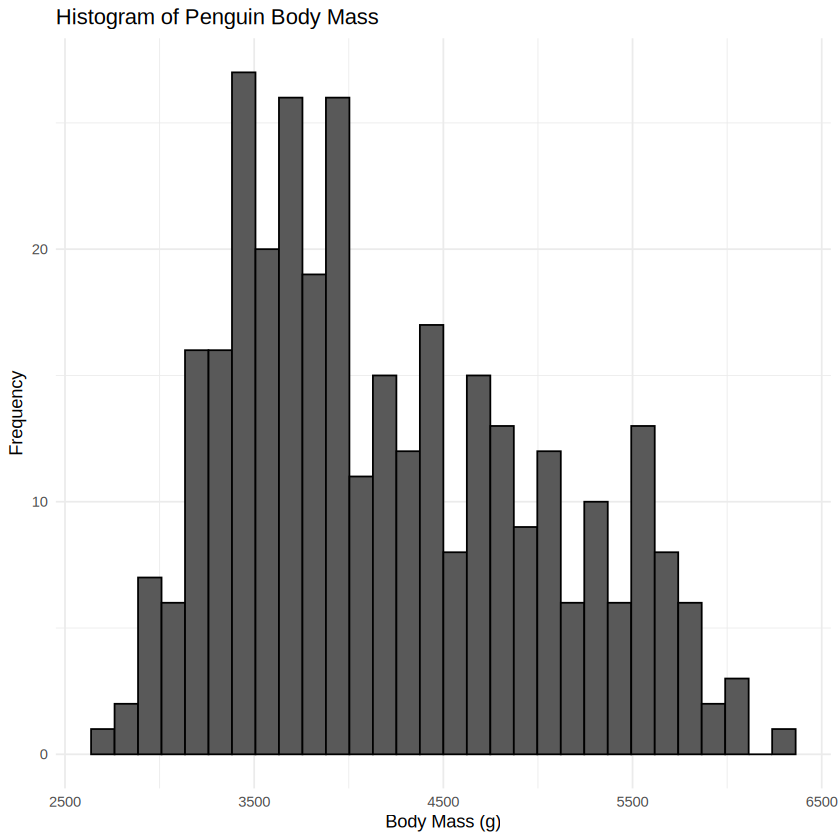

In [16]:
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(
    bins = 30,
    color = "black"
  ) +
  labs(
    title = "Histogram of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

Species-wise Boxplot

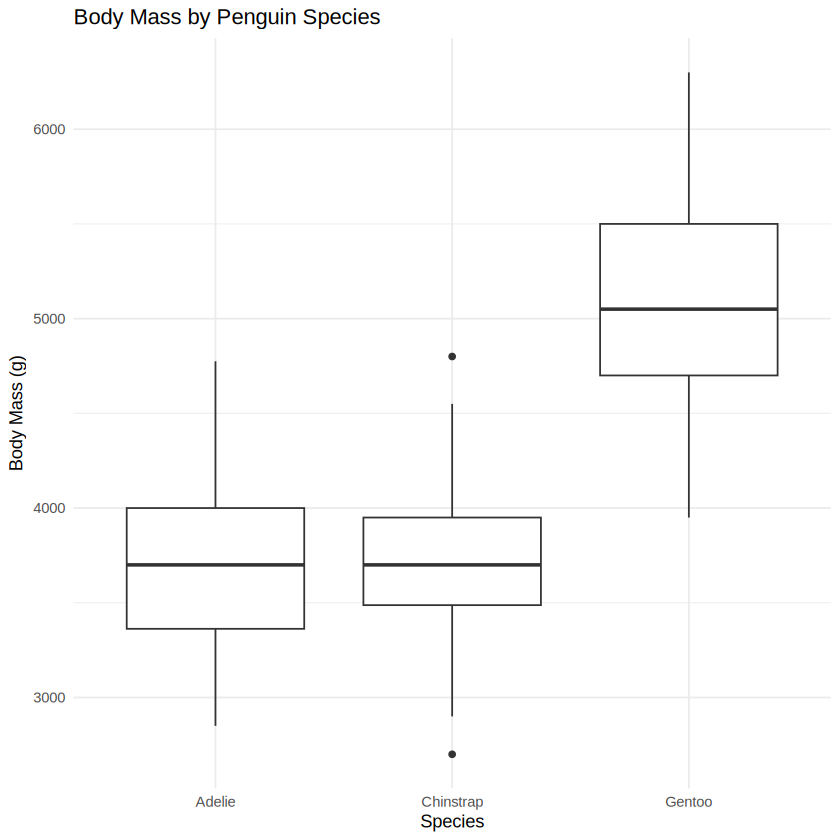

In [17]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

Sex-wise Boxplot

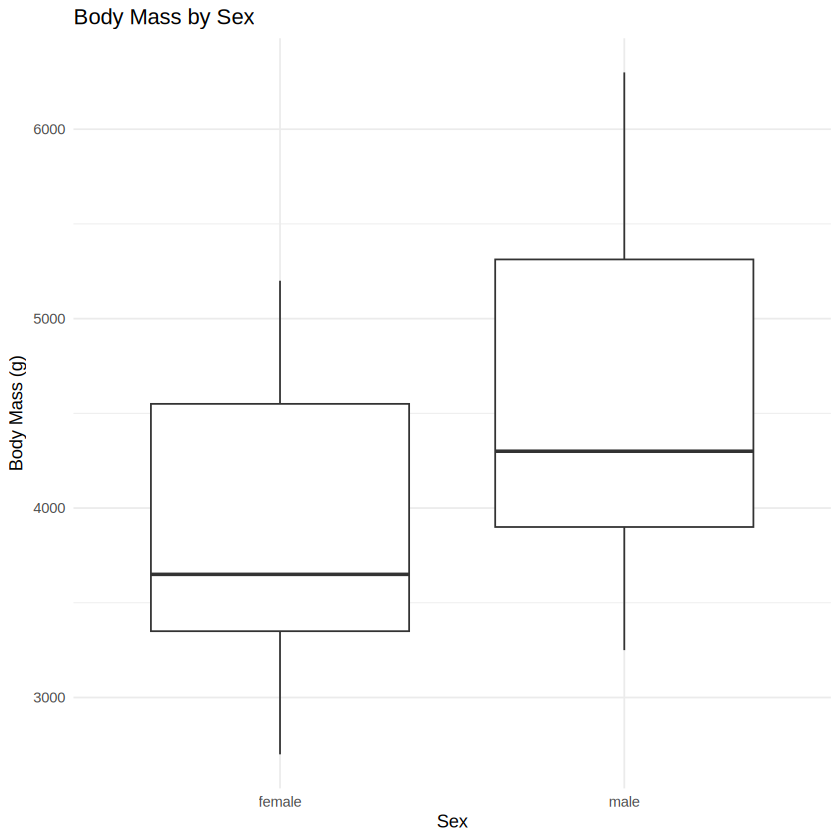

In [18]:
ggplot(penguins_clean, aes(x = sex, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Sex",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

Density Plot

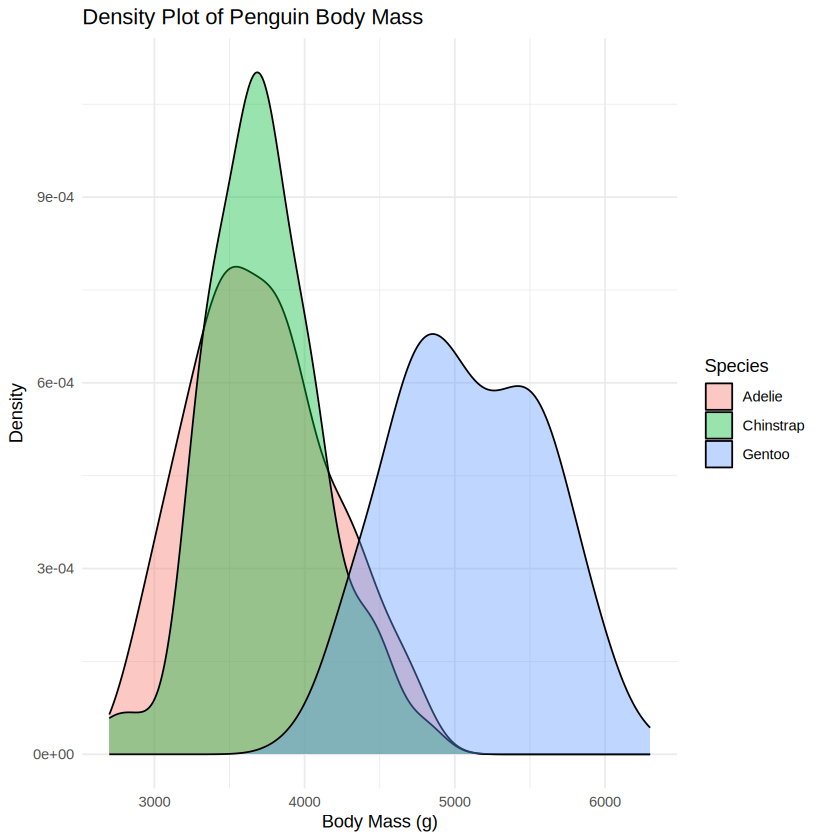

In [19]:
ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.4) +
  labs(
    title = "Density Plot of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species"
  ) +
  theme_minimal()

Shapiro-Wilk Normality Test

In [20]:
male_mass <- penguins_clean %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

female_mass <- penguins_clean %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

shapiro.test(male_mass)

shapiro.test(female_mass)


	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08


QQ Plots

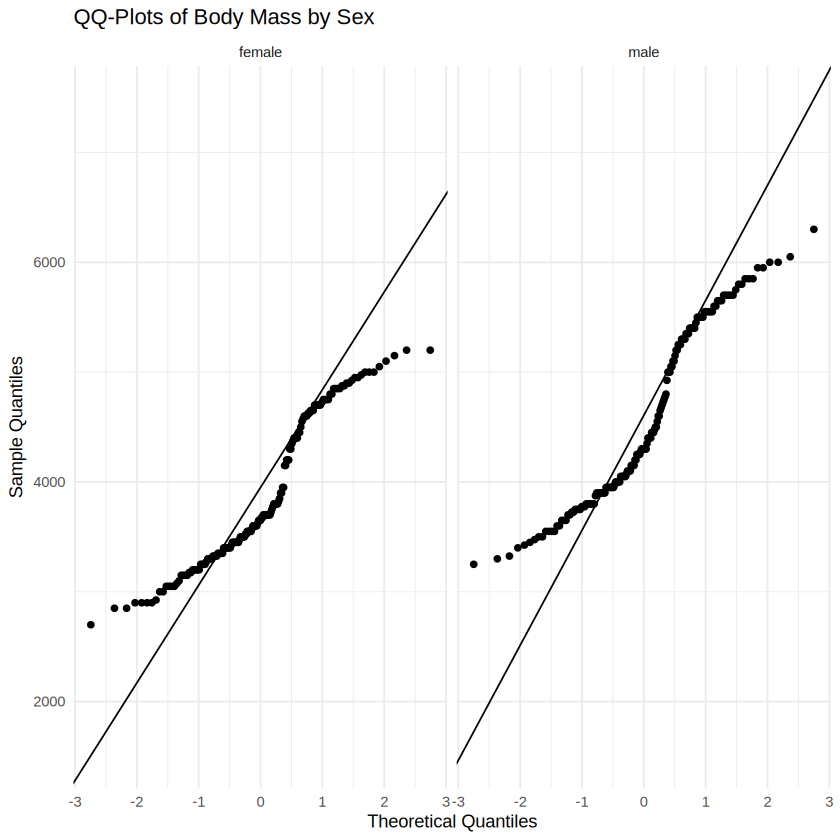

In [21]:
ggplot(penguins_clean, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~sex) +
  labs(
    title = "QQ-Plots of Body Mass by Sex",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()

Independent Two-Sample t-Test

In [22]:
t_test_result <- t.test(
  body_mass_g ~ sex,
  data = penguins_clean,
  var.equal = FALSE
)

t_test_result


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


Cohen's d

In [23]:
cohen_result <- cohen.d(
  body_mass_g ~ sex,
  data = penguins_clean
)

cohen_result


Cohen's d

d estimate: -0.9362048 (large)
95 percent confidence interval:
     lower      upper 
-1.1633158 -0.7090938 


Automatic t-test Interpretation

In [24]:
p_value <- t_test_result$p.value

if (p_value < 0.05) {
  cat("p-value =", p_value, "\n")
  cat("Conclusion: Reject H0.\n")
  cat("There is a statistically significant difference in body mass between male and female penguins.\n")
} else {
  cat("p-value =", p_value, "\n")
  cat("Conclusion: Fail to reject H0.\n")
  cat("There is no statistically significant difference in body mass between male and female penguins.\n")
}

p-value = 4.793891e-16 
Conclusion: Reject H0.
There is a statistically significant difference in body mass between male and female penguins.


One-Way ANOVA

In [25]:
anova_model <- aov(
  body_mass_g ~ species,
  data = penguins_clean
)

summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

ANOVA Assumption: QQ Plot

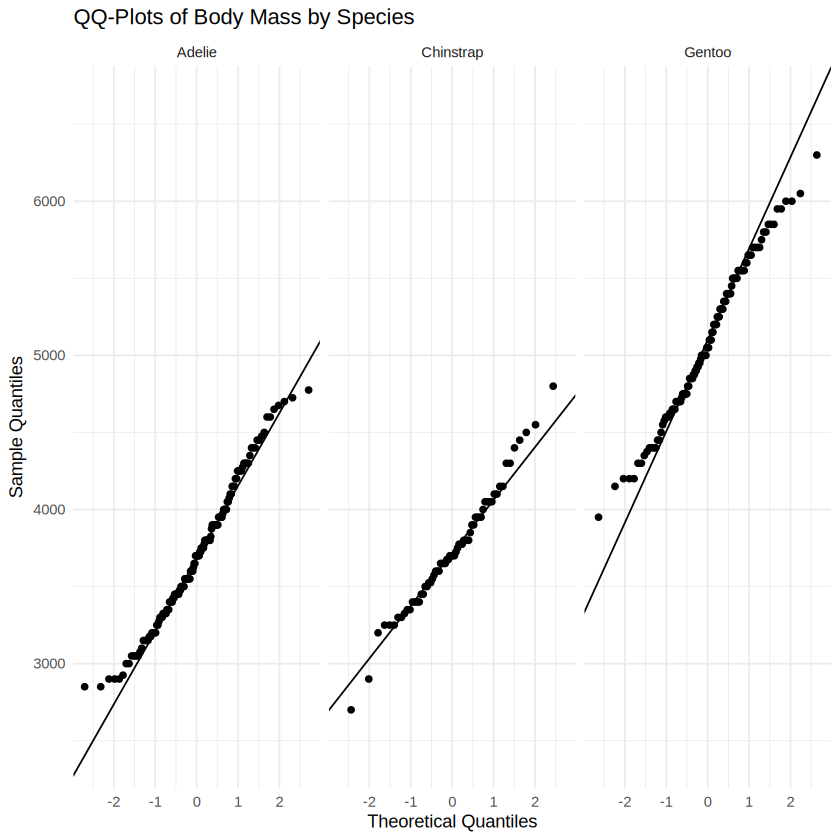

In [26]:
ggplot(penguins_clean, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~species) +
  labs(
    title = "QQ-Plots of Body Mass by Species",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()

Shapiro-Wilk by Species

In [27]:
penguins_clean %>%
  group_by(species) %>%
  summarise(
    p_value = shapiro.test(body_mass_g)$p.value
  )

species,p_value
<fct>,<dbl>
Adelie,0.0423224
Chinstrap,0.5605082
Gentoo,0.2605247


Levene's Test

In [28]:
levene_result <- leveneTest(
  body_mass_g ~ species,
  data = penguins_clean
)

levene_result

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


ANOVA Result

In [29]:
anova_result <- summary(anova_model)

anova_result

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [30]:
anova_table <- summary(anova_model)[[1]]

F_value <- anova_table$`F value`[1]
p_value_anova <- anova_table$`Pr(>F)`[1]

cat("F-statistic:", F_value, "\n")
cat("p-value:", p_value_anova, "\n")

F-statistic: 341.8949 
p-value: 3.744505e-81 


ANOVA Interpretation

In [31]:
if (p_value_anova < 0.05) {
  cat("Conclusion: Reject H0.\n")
  cat("Mean body mass differs significantly among the penguin species.\n")
} else {
  cat("Conclusion: Fail to reject H0.\n")
  cat("There is no significant difference in mean body mass among the penguin species.\n")
}

Conclusion: Reject H0.
Mean body mass differs significantly among the penguin species.


Tukey HSD

In [32]:
tukey_result <- TukeyHSD(anova_model)

tukey_result

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


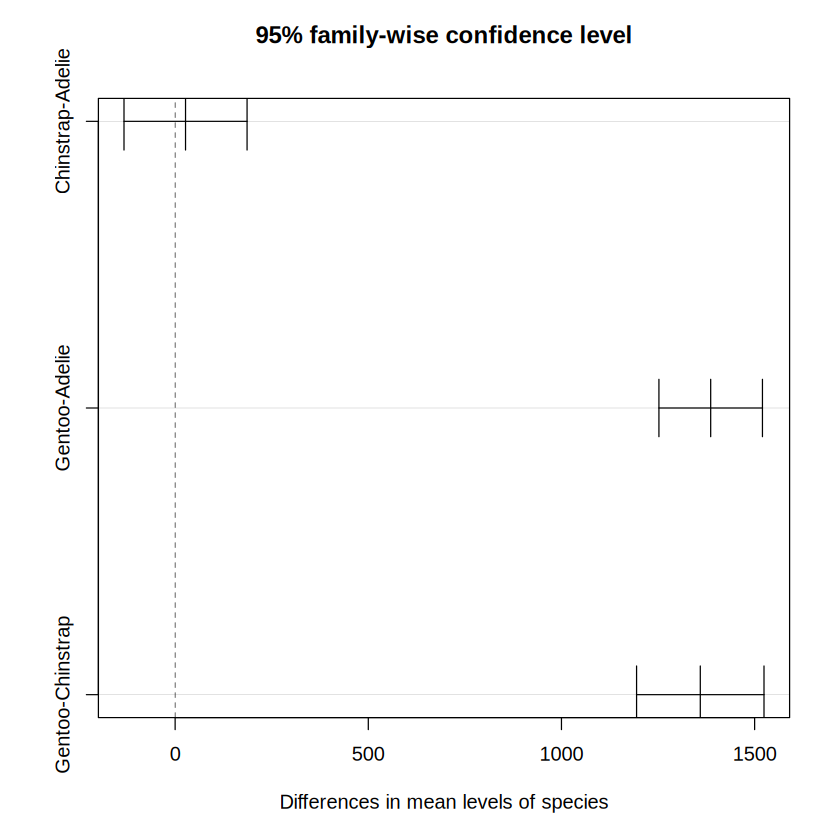

In [33]:
plot(tukey_result)

Kruskal-Wallis Test

In [34]:
kruskal_result <- kruskal.test(
  body_mass_g ~ species,
  data = penguins_clean
)

kruskal_result


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


Compare ANOVA and Kruskal-Wallis

In [35]:
cat("ANOVA p-value:", p_value_anova, "\n")
cat("Kruskal-Wallis p-value:", kruskal_result$p.value, "\n")

if (p_value_anova < 0.05 && kruskal_result$p.value < 0.05) {
  cat("\nBoth tests indicate a statistically significant difference among species.\n")
} else if (p_value_anova >= 0.05 && kruskal_result$p.value >= 0.05) {
  cat("\nBoth tests indicate no statistically significant difference among species.\n")
} else {
  cat("\nThe two tests give different conclusions. The assumptions and distributions should be examined carefully.\n")
}

ANOVA p-value: 3.744505e-81 
Kruskal-Wallis p-value: 8.836877e-47 

Both tests indicate a statistically significant difference among species.


Two-Way ANOVA

In [36]:
two_way_model <- aov(
  body_mass_g ~ species * sex,
  data = penguins_clean
)

summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Two-Way ANOVA Visualization

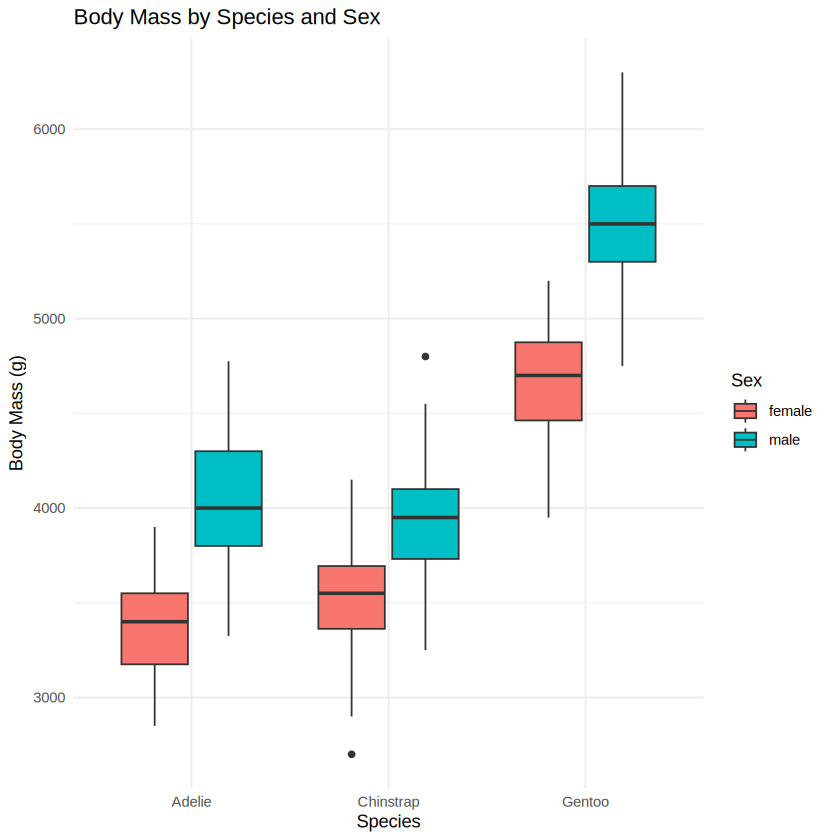

In [37]:
ggplot(
  penguins_clean,
  aes(x = species, y = body_mass_g, fill = sex)
) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Species and Sex",
    x = "Species",
    y = "Body Mass (g)",
    fill = "Sex"
  ) +
  theme_minimal()

Two-Way ANOVA Interpretation

In [38]:
two_way_table <- summary(two_way_model)[[1]]

print(two_way_table)

cat("\nSpecies p-value:",
    two_way_table["species", "Pr(>F)"], "\n")

cat("Sex p-value:",
    two_way_table["sex", "Pr(>F)"], "\n")

cat("Species × Sex interaction p-value:",
    two_way_table["species:sex", "Pr(>F)"], "\n")

             Df    Sum Sq  Mean Sq F value    Pr(>F)    
species       2 145190219 72595110 758.358 < 2.2e-16 ***
sex           1  37090262 37090262 387.460 < 2.2e-16 ***
species:sex   2   1676557   838278   8.757 0.0001973 ***
Residuals   327  31302628    95727                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Species p-value: NA 
Sex p-value: 1.902273e-57 
Species × Sex interaction p-value: 0.0001973489 


Flipper Length by Species

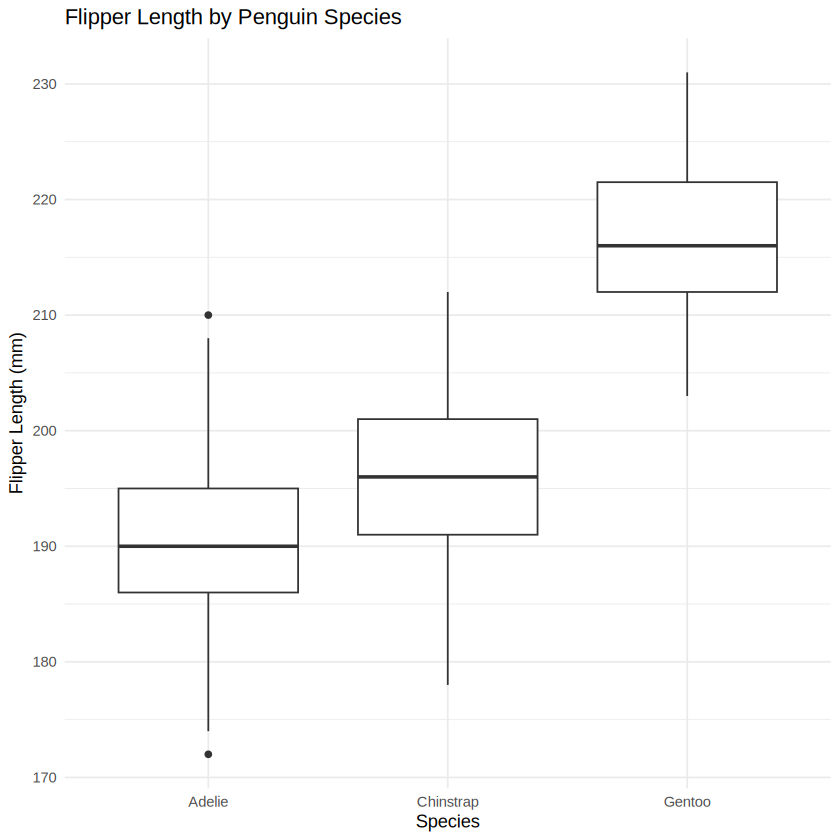

In [39]:
ggplot(
  penguins_clean,
  aes(x = species, y = flipper_length_mm)
) +
  geom_boxplot() +
  labs(
    title = "Flipper Length by Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

Flipper Length ANOVA

In [40]:
flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = penguins_clean
)

summary(flipper_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Flipper Length Tukey Test

In [41]:
TukeyHSD(flipper_anova)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


Flipper Length Kruskal-Wallis

In [42]:
kruskal_flipper <- kruskal.test(
  flipper_length_mm ~ species,
  data = penguins_clean
)

kruskal_flipper


	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


Species Comparison Plot

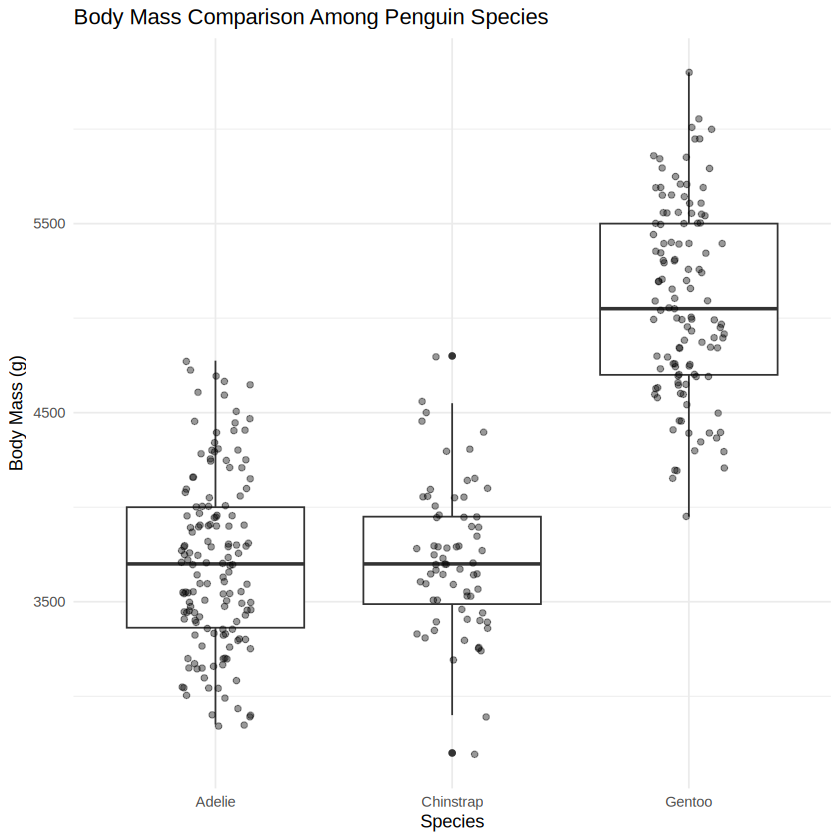

In [43]:
ggplot(
  penguins_clean,
  aes(x = species, y = body_mass_g)
) +
  geom_boxplot() +
  geom_jitter(width = 0.15, alpha = 0.4) +
  labs(
    title = "Body Mass Comparison Among Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

Summary of Main Results

In [44]:
cat("========== FINAL RESULTS ==========\n\n")

cat("1. TWO-SAMPLE T-TEST\n")
cat("p-value:", t_test_result$p.value, "\n")
cat("95% CI:", t_test_result$conf.int[1], "to",
    t_test_result$conf.int[2], "\n\n")

cat("2. ONE-WAY ANOVA\n")
cat("F-statistic:", F_value, "\n")
cat("p-value:", p_value_anova, "\n\n")

cat("3. KRUSKAL-WALLIS TEST\n")
cat("Chi-squared:", kruskal_result$statistic, "\n")
cat("p-value:", kruskal_result$p.value, "\n\n")

cat("4. FLIPPER LENGTH ANOVA\n")
print(summary(flipper_anova))

cat("\n5. TWO-WAY ANOVA\n")
print(summary(two_way_model))

========== FINAL RESULTS ==========

1. TWO-SAMPLE T-TEST
p-value: 4.793891e-16 
95% CI: -840.5783 to -526.2453 

2. ONE-WAY ANOVA
F-statistic: 341.8949 
p-value: 3.744505e-81 

3. KRUSKAL-WALLIS TEST
Chi-squared: 212.0851 
p-value: 8.836877e-47 

4. FLIPPER LENGTH ANOVA
             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

5. TWO-WAY ANOVA
             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


## Conclusion

The Palmer Penguins dataset was analyzed using descriptive statistics,
hypothesis testing, ANOVA and non-parametric methods.

Body mass was summarized using measures such as mean, median, standard
deviation, variance, quartiles, IQR, skewness and kurtosis.

An independent two-sample t-test was used to compare the body mass of
male and female penguins. A one-way ANOVA was performed to determine
whether body mass differed among penguin species, followed by Tukey's
HSD test where applicable.

The Kruskal-Wallis test was also performed as a non-parametric alternative.
A two-way ANOVA was used to study the effects of species and sex and their
interaction on body mass.

Finally, flipper length was compared across penguin species.

The results and visualizations provide statistical evidence about the
differences in physical characteristics among penguin species and sexes.